# FPFS Measurement on Blended Galaxies via `MeasureCoaddsPipe`

This notebook demonstrates how to use `xlens.processor.measure_coadds.MeasureCoaddsPipe`
to run detection and forced FPFS shape measurement on the blended galaxy images from
`AnaCal/examples/fpfs/blended_galaxies/`.

`MeasureCoaddsPipe` is a two-stage pipeline:
1. **Detection** via `AnacalTask` (ngmix Gaussian model fitting)
2. **Forced FPFS measurement** via `FpfsMeasurementTask` at the detected positions

We verify that the measured shear is close to the simulation input
(g1 = -0.02, g2 = 0.0).

In [ ]:
%matplotlib inline

import os
import numpy as np
import fitsio
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm

import lsst.afw.image as afwImage
import lsst.afw.geom as afwGeom
import lsst.geom as geom
from lsst.afw.image import PhotoCalib
from lsst.afw.math import FixedKernel
from lsst.meas.algorithms import KernelPsf
from lsst.skymap.discreteSkyMap import DiscreteSkyMapConfig, DiscreteSkyMap

from xlens.processor.measure_coadds import MeasureCoaddsPipe, MeasureCoaddsPipeConfig
from xlens.utils.handle import make_exposure_handles

## Load Data

We load the same files used by `example_fpfs_blended.py`:
- `image-00000_g1-0_rot0_i.fits` -- 5010x5010 galaxy image (g1=-0.02, g2=0)
- `PSF_Fixed.fits` -- 64x64 constant PSF

In [19]:
data_dir = os.path.dirname(os.path.abspath("__file__"))

gal_array = fitsio.read(os.path.join(data_dir, "image-00000_g1-0_rot0_i.fits"))
psf_array_raw = fitsio.read(os.path.join(data_dir, "PSF_Fixed.fits"))

pixel_scale = 0.2
mag_zero = 30.0
noise_variance = 0.23 ** 2.0
ny, nx = gal_array.shape

print(f"Galaxy image shape: {gal_array.shape}")
print(f"PSF image shape:    {psf_array_raw.shape}")

Galaxy image shape: (5010, 5010)
PSF image shape:    (64, 64)


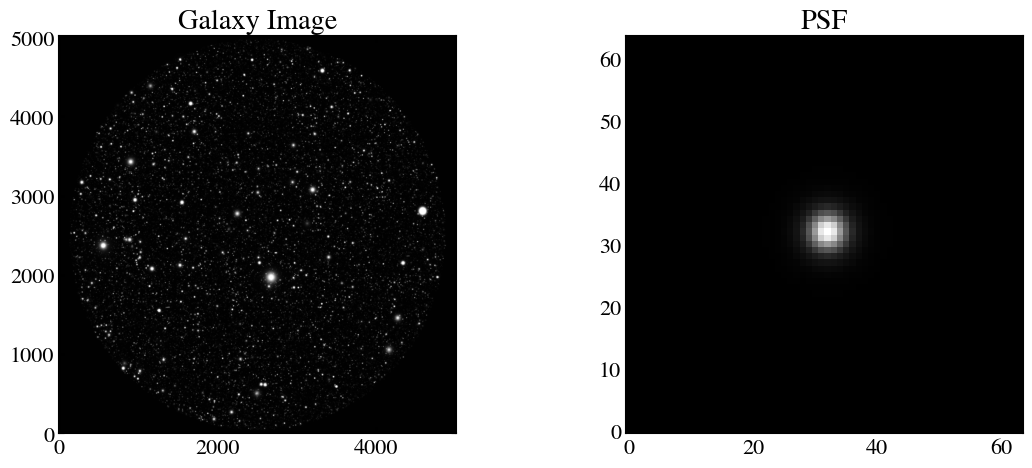

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(
    gal_array,
    aspect="equal",
    cmap="Greys_r",
    origin="lower",
    norm=simple_norm(gal_array, "asinh", asinh_a=0.2, min_cut=-0.1, max_cut=30),
)
axes[0].set_title("Galaxy Image")

axes[1].imshow(psf_array_raw, cmap="Greys_r", origin="lower")
axes[1].set_title("PSF")

plt.tight_layout()
plt.show()

## Build LSST ExposureF from Raw Arrays

`MeasureCoaddsPipe` expects LSST exposures (with WCS, PSF, PhotoCalib).
We construct one from the raw FITS data.

In [21]:
exposure = afwImage.ExposureF(nx, ny)
exposure.image.array[:] = gal_array.astype(np.float32)
exposure.variance.array[:] = noise_variance

# Constant PSF from the FITS file
kernel = FixedKernel(afwImage.ImageD(psf_array_raw.astype(np.float64)))
exposure.setPsf(KernelPsf(kernel))

# Simple TAN WCS centred at (0, 0)
crpix = geom.Point2D(nx / 2, ny / 2)
crval = geom.SpherePoint(0.0, 0.0, geom.degrees)
cdMatrix = afwGeom.makeCdMatrix(scale=pixel_scale * geom.arcseconds)
exposure.setWcs(afwGeom.makeSkyWcs(crpix=crpix, crval=crval, cdMatrix=cdMatrix))

# PhotoCalib so that prepare_data recovers mag_zero = 30
AB_FLUX = 3631.0e9  # nJy
exposure.setPhotoCalib(PhotoCalib(AB_FLUX / 10.0 ** (mag_zero * 0.4)))

# Verify
recovered_mz = np.log10(
    exposure.getPhotoCalib().getInstFluxAtZeroMagnitude()
) / 0.4
print(f"pixel_scale: {exposure.getWcs().getPixelScale().asArcseconds():.4f}")
print(f"mag_zero:    {recovered_mz:.4f}")

pixel_scale: 0.2000
mag_zero:    29.9999


## Prepare Butler-like Infrastructure

`MeasureCoaddsPipe.run()` expects deferred exposure handles (with a
`dataId`), a SkyMap, and tract/patch identifiers.  We create lightweight
stand-ins for each.

In [ ]:
# Wrap the constructed exposure in a stand-in butler handle dict.
exposure_handles_dict = make_exposure_handles(
    exposure, tract=0, patch=0, band="i", instrument="LSSTCam",
)

In [23]:
# SkyMap covering the image
skymap_config = DiscreteSkyMapConfig()
skymap_config.projection = "TAN"
skymap_config.raList = [0.0]
skymap_config.decList = [0.0]
skymap_config.radiusList = [0.15]
skymap_config.patchInnerDimensions = [nx, ny]
skymap_config.patchBorder = 0
skymap_config.pixelScale = pixel_scale
skymap_config.tractOverlap = 0.0
skymap = DiscreteSkyMap(skymap_config)

## Configure and Run `MeasureCoaddsPipe`

In [24]:
config = MeasureCoaddsPipeConfig()

# Detection (AnacalTask)
config.anacal.force_size = True
config.anacal.force_center = True
config.anacal.do_noise_bias_correction = False  # no noise array

# Forced FPFS measurement
config.fpfs.sigma_shapelets = 0.52
config.fpfs.sigma_shapelets1 = 0.45
config.fpfs.sigma_shapelets2 = 0.55
config.fpfs.bound = 35
config.fpfs.do_noise_bias_correction = False  # no noise array

pipe = MeasureCoaddsPipe(config=config)

In [ ]:
result = pipe.run(
    exposure_handles_dict=exposure_handles_dict,
    corr_array=None,
    skyMap=skymap,
    tract=0,
    patch=0,
)

catalog = result.anacalCatalog
print(f"Detected and measured {len(catalog)} objects")

## Shear Estimation

The simulation was generated with input shear **g1 = -0.02, g2 = 0.0**.

`MeasureCoaddsPipe` uses `wsel` / `dwsel_dg{1,2}` (from the AnacalTask
detection stage) as the selection weight, and band-prefixed FPFS
ellipticities `i_fpfs{1,2}_e{1,2}` from the forced measurement stage.

In [26]:
input_g1 = -0.02
input_g2 = 0.0


def estimate_shear(cat, e1_col, e2_col,
                   w="wsel", dw_dg1="dwsel_dg1", dw_dg2="dwsel_dg2"):
    """Estimate g1 and g2 from a MeasureCoaddsPipe catalog."""
    de1_col = e1_col.replace("_e1", "_de1_dg1")
    de2_col = e2_col.replace("_e2", "_de2_dg2")

    e1 = cat[w] * cat[e1_col]
    de1 = cat[dw_dg1] * cat[e1_col] + cat[w] * cat[de1_col]
    g1 = np.sum(e1) / np.sum(de1)

    e2 = cat[w] * cat[e2_col]
    de2 = cat[dw_dg2] * cat[e2_col] + cat[w] * cat[de2_col]
    g2 = np.sum(e2) / np.sum(de2)
    return g1, g2


# Detection-kernel ellipticities (from AnacalTask, not band-prefixed)
g1_det, g2_det = estimate_shear(catalog, "fpfs_e1", "fpfs_e2")
print(f"Det kernel    g1: {g1_det:.6f}  g2: {g2_det:.6f}  (input: {input_g1}, {input_g2})")

# Kernel 1 (forced, band-prefixed)
g1_k1, g2_k1 = estimate_shear(catalog, "lsst_i_fpfs1_e1", "lsst_i_fpfs1_e2")
print(f"Kernel 1      g1: {g1_k1:.6f}  g2: {g2_k1:.6f}  (input: {input_g1}, {input_g2})")

# Kernel 2 (forced, band-prefixed)
g1_k2, g2_k2 = estimate_shear(catalog, "lsst_i_fpfs2_e1", "lsst_i_fpfs2_e2")
print(f"Kernel 2      g1: {g1_k2:.6f}  g2: {g2_k2:.6f}  (input: {input_g1}, {input_g2})")

Det kernel    g1: -0.021013  g2: 0.000487  (input: -0.02, 0.0)
Kernel 1      g1: -0.020542  g2: 0.000761  (input: -0.02, 0.0)
Kernel 2      g1: -0.020935  g2: 0.000534  (input: -0.02, 0.0)


## Validate Measured Shear Against Input

With a single realisation of ~17k blended galaxies, shape noise limits
precision to O(1e-3).

In [27]:
atol = 2e-3

print(f"Input shear: g1 = {input_g1}, g2 = {input_g2}")
print(f"Tolerance:   {atol}")
print()

for label, g1_meas, g2_meas in [
    ("Det kernel", g1_det, g2_det),
    ("Kernel 1  ", g1_k1, g2_k1),
    ("Kernel 2  ", g1_k2, g2_k2),
]:
    dg1 = g1_meas - input_g1
    dg2 = g2_meas - input_g2
    ok1 = "PASS" if abs(dg1) < atol else "FAIL"
    ok2 = "PASS" if abs(dg2) < atol else "FAIL"
    print(
        f"  {label}: g1 = {g1_meas:.6f} (diff {dg1:+.6f}) [{ok1}]"
        f"   g2 = {g2_meas:.6f} (diff {dg2:+.6f}) [{ok2}]"
    )

np.testing.assert_allclose(g1_det, input_g1, atol=atol, err_msg="Det kernel g1")
np.testing.assert_allclose(g2_det, input_g2, atol=atol, err_msg="Det kernel g2")
np.testing.assert_allclose(g1_k1, input_g1, atol=atol, err_msg="Kernel1 g1")
np.testing.assert_allclose(g2_k1, input_g2, atol=atol, err_msg="Kernel1 g2")
np.testing.assert_allclose(g1_k2, input_g1, atol=atol, err_msg="Kernel2 g1")
np.testing.assert_allclose(g2_k2, input_g2, atol=atol, err_msg="Kernel2 g2")

print("\nAll shear estimates are consistent with the input (g1=-0.02, g2=0.0).")

Input shear: g1 = -0.02, g2 = 0.0
Tolerance:   0.002

  Det kernel: g1 = -0.021013 (diff -0.001013) [PASS]   g2 = 0.000487 (diff +0.000487) [PASS]
  Kernel 1  : g1 = -0.020542 (diff -0.000542) [PASS]   g2 = 0.000761 (diff +0.000761) [PASS]
  Kernel 2  : g1 = -0.020935 (diff -0.000935) [PASS]   g2 = 0.000534 (diff +0.000534) [PASS]

All shear estimates are consistent with the input (g1=-0.02, g2=0.0).
